In [13]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti


In [14]:
import os
import gc
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression

from sentence_transformers import SentenceTransformer

In [15]:

DATA_DIR = "../datasets/processed"


def load_all_datasets():
    paths = {
        "imdb": os.path.join(DATA_DIR, "imdb.csv"),
        "rotten": os.path.join(DATA_DIR, "rotten.csv"),
        "amazon": os.path.join(DATA_DIR, "amazon.csv"),
        "yelp": os.path.join(DATA_DIR, "yelp.csv"),
    }

    datasets = {}

    for name, path in paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"Nie znaleziono pliku: {path}")

        df = pd.read_csv(path)
        df = df[["text", "label"]].dropna()
        df["label"] = df["label"].astype(int)
        datasets[name] = df

    return datasets


datasets = load_all_datasets()

In [16]:

EMBEDDER_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBEDDER_NAME, device=device)
embedder.max_seq_length = 256

print("Embedder device:", embedder.device)
print("Max seq length:", embedder.max_seq_length)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18964.59it/s]


Embedder device: cuda:0
Max seq length: 256


In [17]:

def encode_texts(texts, batch_size=64):
    return embedder.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

In [18]:

def precompute_domain_embeddings(datasets, batch_size=64):
    embeddings = {}

    for domain, df in datasets.items():
        print(f"\nEncoding domain: {domain}")
        embeddings[domain] = encode_texts(df["text"].values, batch_size=batch_size)
        print(f"Shape: {embeddings[domain].shape}")

    return embeddings


domain_embeddings = precompute_domain_embeddings(datasets, batch_size=64)


Encoding domain: imdb


Batches: 100%|██████████| 782/782 [00:22<00:00, 34.79it/s]


Shape: (50000, 384)

Encoding domain: rotten


Batches: 100%|██████████| 782/782 [00:04<00:00, 156.84it/s]


Shape: (49999, 384)

Encoding domain: amazon


Batches: 100%|██████████| 329/329 [00:04<00:00, 70.10it/s] 


Shape: (21055, 384)

Encoding domain: yelp


Batches: 100%|██████████| 157/157 [00:03<00:00, 51.41it/s] 

Shape: (10000, 384)


In [19]:

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

In [20]:

def run_ood_experiment_minilm(
        datasets,
        embeddings,
        n_splits=5
):
    results = []
    training_logs = []

    domains = list(datasets.keys())

    for train_domain in domains:
        print("\n" + "=" * 80)
        print(f"TRAIN DOMAIN: {train_domain}")
        print("=" * 80)

        df = datasets[train_domain].reset_index(drop=True)
        X = embeddings[train_domain]
        y = df["label"].values.astype(int)

        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

        for fold_id, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
            print(f"\nFold {fold_id}/{n_splits}")

            X_train = X[train_idx]
            y_train = y[train_idx]

            X_val = X[val_idx]
            y_val = y[val_idx]

            clf = LogisticRegression(
                max_iter=5000,
                random_state=42,
                class_weight="balanced",
                solver="liblinear"
            )

            clf.fit(X_train, y_train)


            train_pred = clf.predict(X_train)
            val_pred = clf.predict(X_val)

            train_metrics = compute_metrics(y_train, train_pred)
            val_metrics = compute_metrics(y_val, val_pred)

            training_logs.append({
                "train_domain": train_domain,
                "fold": fold_id,
                "train_accuracy": train_metrics["accuracy"],
                "train_balanced_accuracy": train_metrics["balanced_accuracy"],
                "train_precision": train_metrics["precision"],
                "train_recall": train_metrics["recall"],
                "train_f1": train_metrics["f1"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_f1": val_metrics["f1"],
            })

            print(
                f"IND | F1: {val_metrics['f1']:.4f} | "
                f"Acc: {val_metrics['accuracy']:.4f} | "
                f"Prec: {val_metrics['precision']:.4f} | "
                f"Rec: {val_metrics['recall']:.4f}"
            )

            results.append({
                "train_domain": train_domain,
                "test_domain": train_domain,
                "fold": fold_id,
                "accuracy": val_metrics["accuracy"],
                "precision": val_metrics["precision"],
                "recall": val_metrics["recall"],
                "f1": val_metrics["f1"],
                "eval_type": "IND"
            })


            for test_domain, test_df in datasets.items():
                if test_domain == train_domain:
                    continue

                X_test = embeddings[test_domain]
                y_test = test_df["label"].values.astype(int)

                test_pred = clf.predict(X_test)
                test_metrics = compute_metrics(y_test, test_pred)

                print(
                    f"OOD {train_domain} → {test_domain} | "
                    f"F1: {test_metrics['f1']:.4f} | "
                    f"Acc: {test_metrics['accuracy']:.4f} | "
                    f"Prec: {test_metrics['precision']:.4f} | "
                    f"Rec: {test_metrics['recall']:.4f}"
                )

                results.append({
                    "train_domain": train_domain,
                    "test_domain": test_domain,
                    "fold": fold_id,
                    "accuracy": test_metrics["accuracy"],
                    "precision": test_metrics["precision"],
                    "recall": test_metrics["recall"],
                    "f1": test_metrics["f1"],
                    "eval_type": "OOD"
                })

            del clf
            gc.collect()

    return pd.DataFrame(training_logs), pd.DataFrame(results)

In [21]:

training_logs_minilm, ood_results_minilm = run_ood_experiment_minilm(
    datasets=datasets,
    embeddings=domain_embeddings,
    n_splits=5
)


TRAIN DOMAIN: imdb

Fold 1/5
IND | F1: 0.8274 | Acc: 0.8262 | Prec: 0.8216 | Rec: 0.8334
OOD imdb → rotten | F1: 0.7255 | Acc: 0.7071 | Prec: 0.6826 | Rec: 0.7742
OOD imdb → amazon | F1: 0.6036 | Acc: 0.6161 | Prec: 0.4497 | Rec: 0.9178
OOD imdb → yelp | F1: 0.9193 | Acc: 0.8639 | Prec: 0.9071 | Rec: 0.9319

Fold 2/5
IND | F1: 0.8242 | Acc: 0.8250 | Prec: 0.8282 | Rec: 0.8202
OOD imdb → rotten | F1: 0.7243 | Acc: 0.7083 | Prec: 0.6867 | Rec: 0.7663
OOD imdb → amazon | F1: 0.5817 | Acc: 0.6125 | Prec: 0.4432 | Rec: 0.8461
OOD imdb → yelp | F1: 0.9180 | Acc: 0.8619 | Prec: 0.9076 | Rec: 0.9286

Fold 3/5
IND | F1: 0.8240 | Acc: 0.8232 | Prec: 0.8203 | Rec: 0.8278
OOD imdb → rotten | F1: 0.7244 | Acc: 0.7059 | Prec: 0.6815 | Rec: 0.7732
OOD imdb → amazon | F1: 0.5837 | Acc: 0.5746 | Prec: 0.4240 | Rec: 0.9366
OOD imdb → yelp | F1: 0.9198 | Acc: 0.8637 | Prec: 0.9012 | Rec: 0.9392

Fold 4/5
IND | F1: 0.8256 | Acc: 0.8250 | Prec: 0.8228 | Rec: 0.8284
OOD imdb → rotten | F1: 0.7245 | Acc: 0.

In [22]:

SAVE_DIR = "./results"
os.makedirs(SAVE_DIR, exist_ok=True)

training_logs_minilm.to_csv(os.path.join(SAVE_DIR, "minilm_training_logs.csv"), index=False)
ood_results_minilm.to_csv(os.path.join(SAVE_DIR, "minilm_ood_results.csv"), index=False)

print("Saved:")
print(" - minilm_training_logs.csv")
print(" - minilm_ood_results.csv")

Saved:
 - minilm_training_logs.csv
 - minilm_ood_results.csv


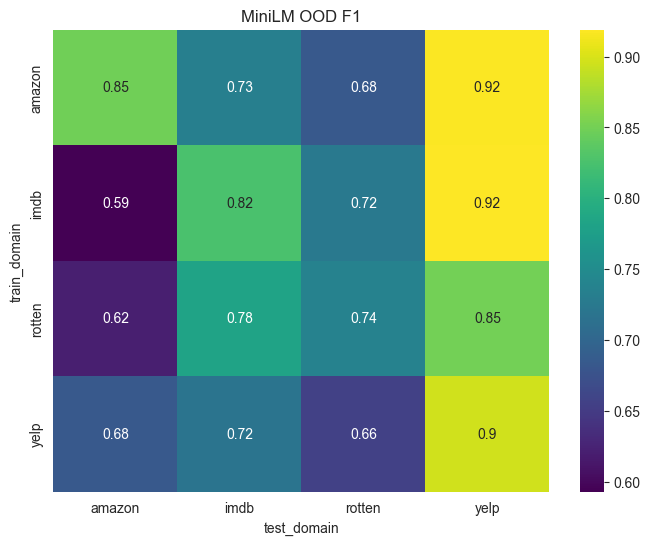

In [23]:

import seaborn as sns
import matplotlib.pyplot as plt

pivot = ood_results_minilm.groupby(
    ["train_domain", "test_domain"]
)["f1"].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("MiniLM OOD F1")
plt.show()

<Figure size 1000x500 with 0 Axes>

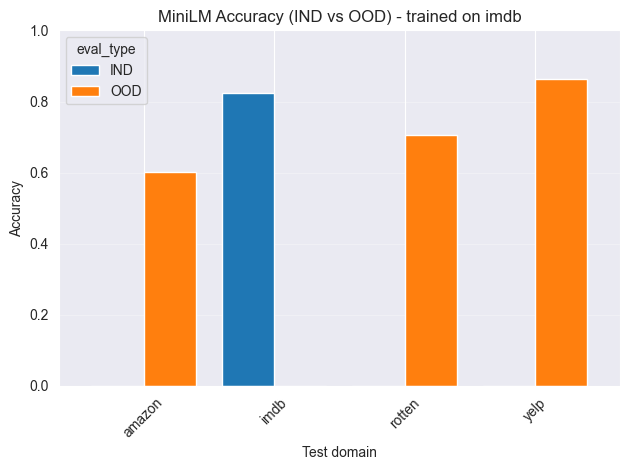

<Figure size 1000x500 with 0 Axes>

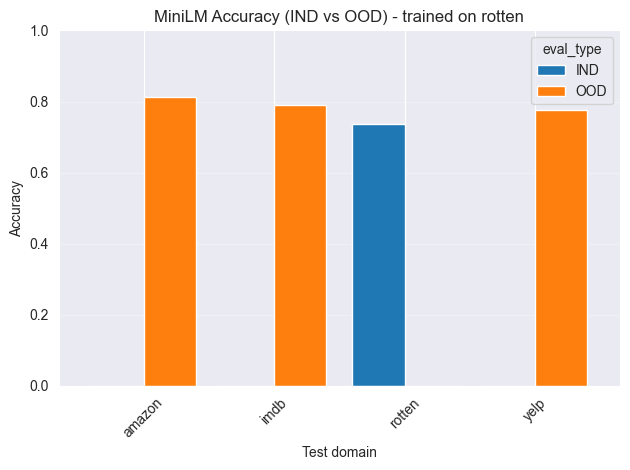

<Figure size 1000x500 with 0 Axes>

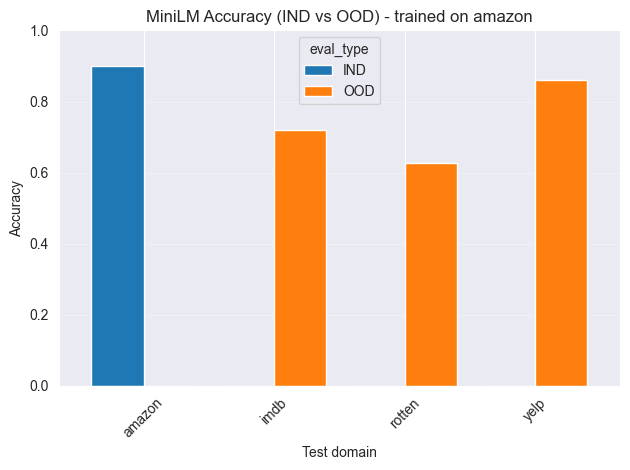

<Figure size 1000x500 with 0 Axes>

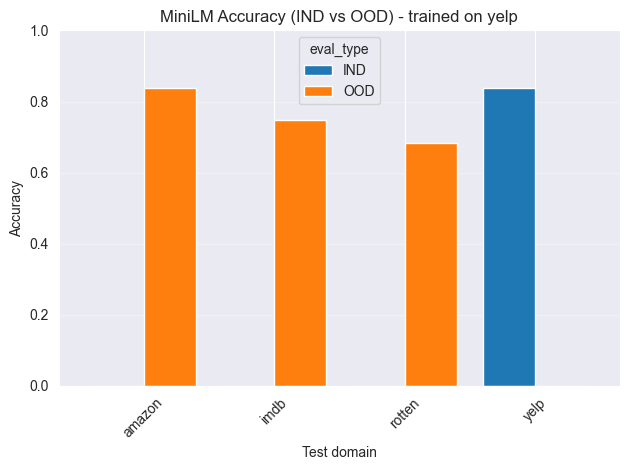

In [24]:
import matplotlib.pyplot as plt

df = ood_results_minilm

train_domains = df["train_domain"].unique()

for train_domain in train_domains:

    subset = df[df["train_domain"] == train_domain]

    pivot = subset.pivot_table(
        index="test_domain",
        columns="eval_type",
        values="accuracy",
        aggfunc="mean"
    )

    pivot = pivot.sort_index()

    plt.figure(figsize=(10, 5))

    ax = pivot.plot(
        kind="bar",
        width=0.8
    )

    plt.title(f"MiniLM Accuracy (IND vs OOD) - trained on {train_domain}")
    plt.xlabel("Test domain")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=45)

    plt.ylim(0, 1)

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

plt.show()